In [2]:
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from skimage import data
from skimage.morphology import watershed, disk
from skimage.filters import rank
from skimage.util import img_as_ubyte

In [3]:
image = img_as_ubyte(data.camera())

denoised = rank.median(image, disk(2))

markers = rank.gradient(denoised, disk(5)) < 10
markers = ndi.label(markers)[0]

gradient = rank.gradient(denoised, disk(2))

labels = watershed(gradient, markers)

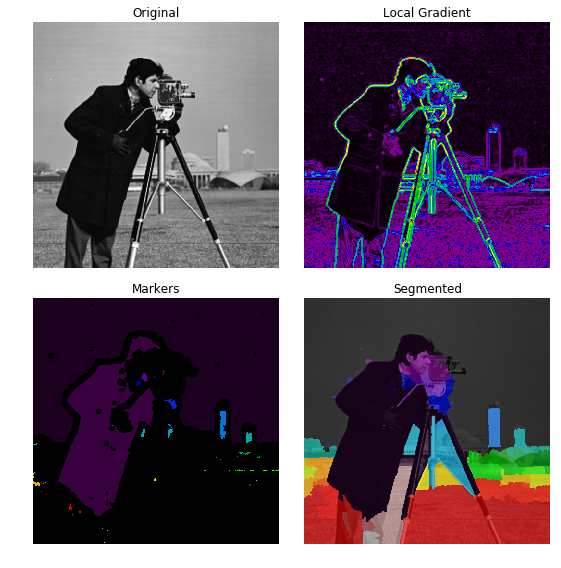

In [4]:
# display results
fig, axes = plt.subplots(nrows=2, ncols=2, 
                         figsize=(8, 8),
                         sharex=True, sharey=True)
ax = axes.ravel()
ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title("Original")

ax[1].imshow(gradient, cmap=plt.cm.nipy_spectral)
ax[1].set_title("Local Gradient")

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title("Markers")

ax[3].imshow(image, cmap=plt.cm.gray)
ax[3].imshow(labels, cmap=plt.cm.nipy_spectral, 
             alpha=.7)
ax[3].set_title("Segmented")

for a in ax:
    a.axis('off')

fig.tight_layout()
plt.show()